In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

Loding Data Set

In [2]:
df=pd.read_excel(r"B:\New folder\Random Forest\glass.xlsx")
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


Data Preprossing

In [3]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [4]:
df.drop_duplicates(inplace=True)

Data Visualization

<Axes: >

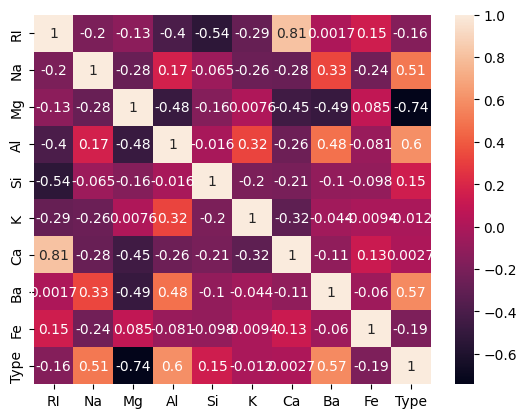

In [5]:
sns.heatmap(df.corr(),annot=True)

<function matplotlib.pyplot.show(close=None, block=None)>

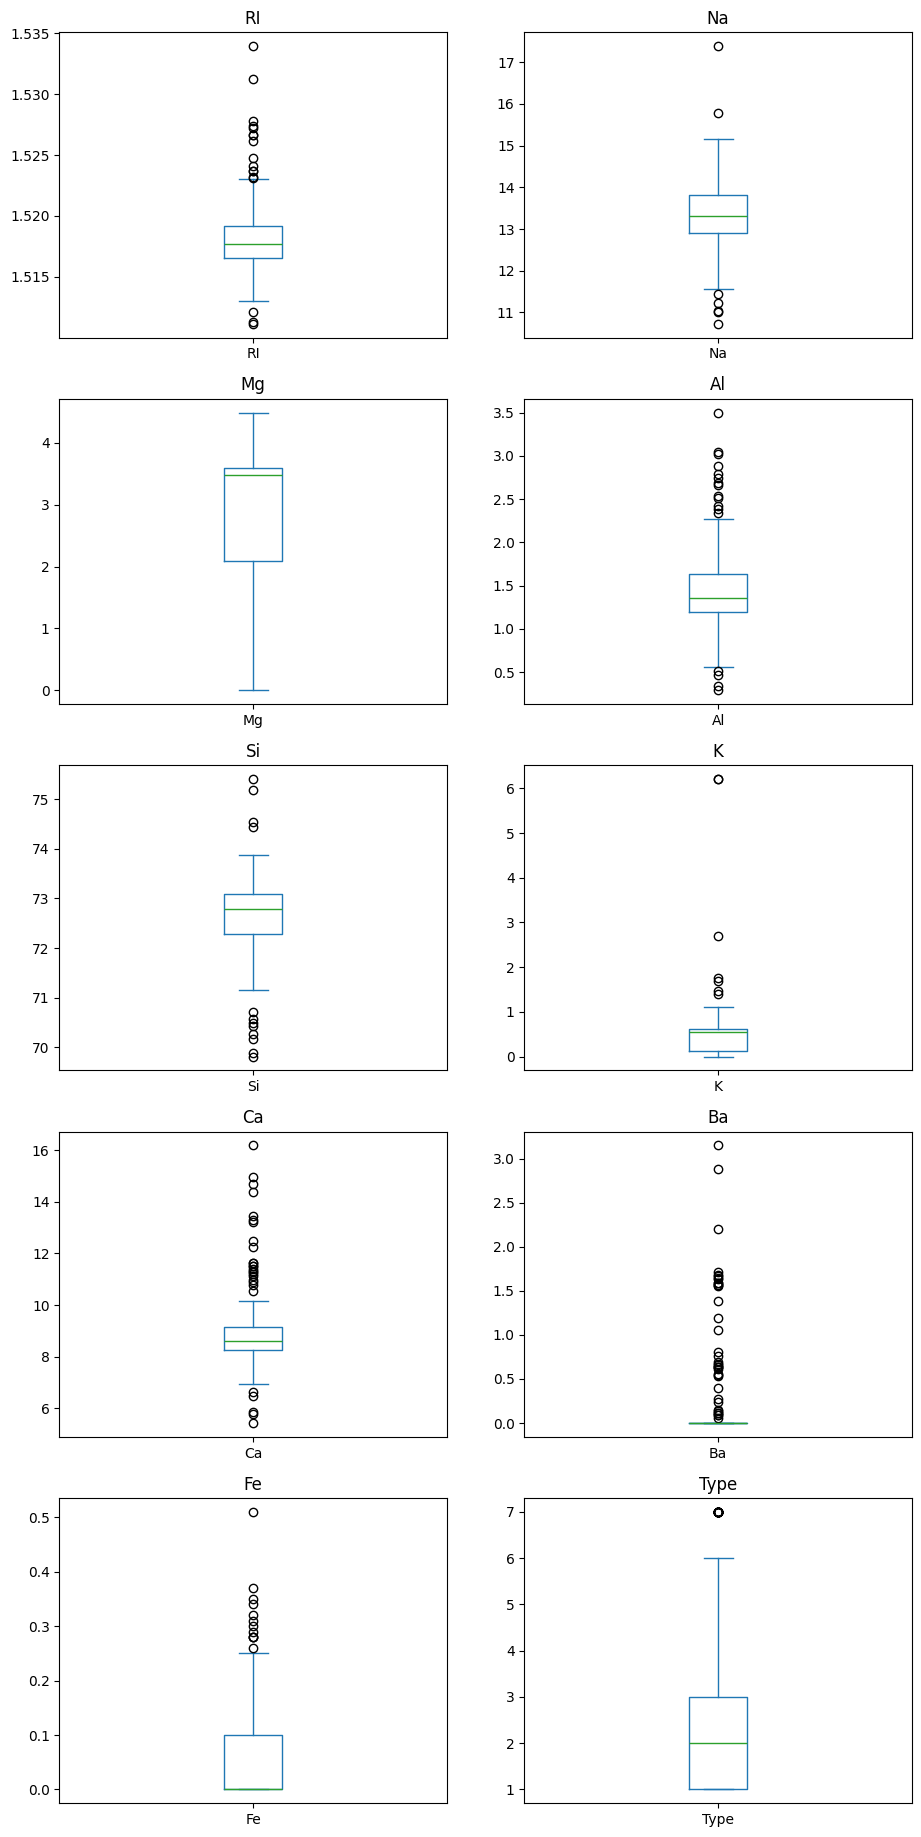

In [6]:
fig, box=plt.subplots(5,2, figsize=(11,23))

(df['RI']).plot(kind='box', ax=box[0,0])
box[0,0].set_title('RI')

(df['Na']).plot(kind='box', ax=box[0,1])
box[0,1].set_title('Na')

(df['Mg']).plot(kind='box', ax=box[1,0])
box[1,0].set_title('Mg')

(df['Al']).plot(kind='box', ax=box[1,1])
box[1,1].set_title('Al')

(df['Si']).plot(kind='box', ax=box[2,0])
box[2,0].set_title('Si')

(df['K']).plot(kind='box', ax=box[2,1])
box[2,1].set_title('K')

(df['Ca']).plot(kind='box', ax=box[3,0])
box[3,0].set_title('Ca')

(df['Ba']).plot(kind='box', ax=box[3,1])
box[3,1].set_title('Ba')

(df['Fe']).plot(kind='box', ax=box[4,0])
box[4,0].set_title('Fe')

(df['Type']).plot(kind='box', ax=box[4,1])
box[4,1].set_title('Type')

plt.show

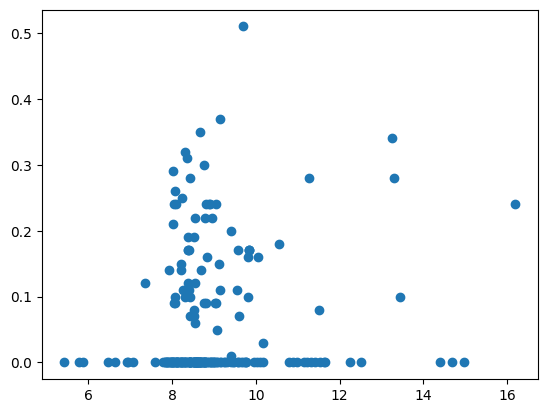

In [7]:
plt.scatter(x='Ca',y='Fe',data=df)

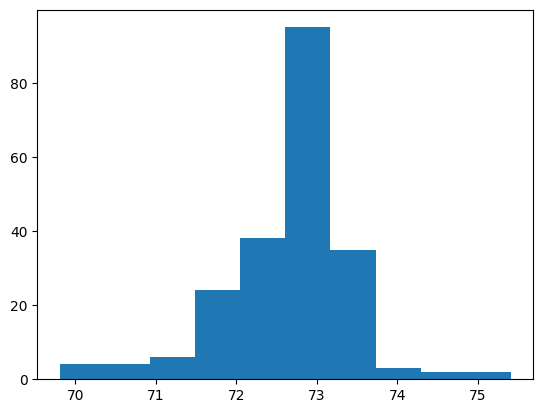

In [8]:
plt.hist(x='Si',data=df)
plt.show()

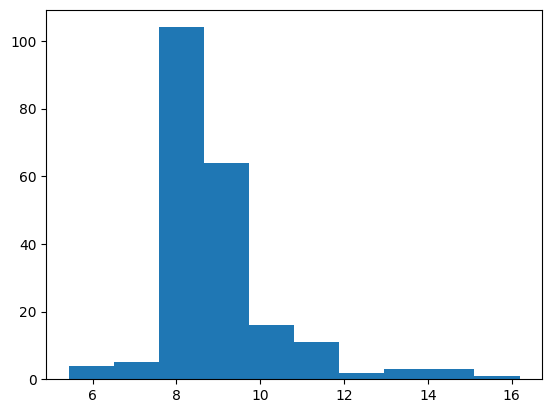

In [9]:
plt.hist(x='Ca',data=df)
plt.show()

In [10]:
df = pd.get_dummies(df, drop_first=True) 
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


There is No  Handle Categorical Variables to do Encoding.

Standarding The Data

In [11]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

df_scaler=scaler.fit_transform(df)
df_scaler

array([[ 0.87984017,  0.28955813,  1.25723832, ..., -0.35380764,
        -0.58830108, -0.85170346],
       [-0.24381562,  0.59640332,  0.63931074, ..., -0.35380764,
        -0.58830108, -0.85170346],
       [-0.71641202,  0.15454625,  0.6045957 , ..., -0.35380764,
        -0.58830108, -0.85170346],
       ...,
       [ 0.76086485,  1.17327228, -1.86017161, ...,  2.94550057,
        -0.58830108,  2.0051916 ],
       [-0.60735132,  1.19781989, -1.86017161, ...,  2.80467644,
        -0.58830108,  2.0051916 ],
       [-0.40905912,  1.01371278, -1.86017161, ...,  3.00585377,
        -0.58830108,  2.0051916 ]])

Knowing The Max,Min values In The data Set

In [12]:
from sklearn.preprocessing import MinMaxScaler
min_max=MinMaxScaler()

min_max_scaler=min_max.fit_transform(df)
min_max_scaler

array([[0.43283582, 0.43759398, 1.        , ..., 0.        , 0.        ,
        0.        ],
       [0.28358209, 0.47518797, 0.80178174, ..., 0.        , 0.        ,
        0.        ],
       [0.22080773, 0.42105263, 0.79064588, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.41703248, 0.54586466, 0.        , ..., 0.52063492, 0.        ,
        1.        ],
       [0.23529412, 0.54887218, 0.        , ..., 0.4984127 , 0.        ,
        1.        ],
       [0.26163301, 0.52631579, 0.        , ..., 0.53015873, 0.        ,
        1.        ]])

Normalizing The Data Set

In [13]:
from sklearn.preprocessing import Normalizer
nom=Normalizer()

normalizer=nom.fit_transform(df)
normalizer

array([[0.02062272, 0.18493886, 0.06087797, ..., 0.        , 0.        ,
        0.01355857],
       [0.02034864, 0.18624195, 0.04827005, ..., 0.        , 0.        ,
        0.01340835],
       [0.02027973, 0.18097109, 0.04748318, ..., 0.        , 0.        ,
        0.01337554],
       ...,
       [0.02009568, 0.18977016, 0.        , ..., 0.02167292, 0.        ,
        0.09250635],
       [0.01999105, 0.18956111, 0.        , ..., 0.02069617, 0.        ,
        0.09227592],
       [0.02006488, 0.1882021 , 0.        , ..., 0.02208696, 0.        ,
        0.09258009]])

Splitting The Data Set In To Train And Test Set

In [15]:
from sklearn.model_selection import train_test_split

x=df.drop(columns=['Type'])
y=df['Type']

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

Bulding The Model By Using Random Forest Classifier

In [16]:
from sklearn.ensemble import RandomForestClassifier
ram_forest_model=RandomForestClassifier()

ram_forest_model.fit(x_train,y_train)

RandomForestClassifier()

In [17]:
y_pred=ram_forest_model.predict(x_test)

In [18]:
y_test

9      1
198    7
67     1
192    7
118    2
112    2
15     1
87     2
76     2
145    2
183    6
171    5
142    2
74     2
179    6
168    5
191    7
18     1
46     1
185    7
99     2
209    7
211    7
196    7
149    3
105    2
30     1
25     1
176    6
16     1
56     1
139    2
159    3
94     2
70     2
203    7
172    5
153    3
98     2
85     2
102    2
201    7
61     1
Name: Type, dtype: int64

In [19]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

y_pred = ram_forest_model.predict(x_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred,average='macro')
recall = recall_score(y_test, y_pred,average='macro')
f1 = f1_score(y_test, y_pred,average='macro')

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)


print("Accuracy is:",accuracy)
print("precision is:",precision)
print("Recall is:",recall)
print("F1 score is:",f1)
print("Confusion matrix:",conf_matrix)

Accuracy is: 0.8604651162790697
precision is: 0.8942307692307692
Recall is: 0.8814814814814816
F1 score is: 0.8755998051394472
Confusion matrix: [[10  0  0  0  0  0]
 [ 3 11  0  1  0  0]
 [ 0  0  3  0  0  0]
 [ 0  0  0  3  0  0]
 [ 0  1  0  0  2  0]
 [ 0  1  0  0  0  8]]


Ad-Boost Classifier

In [20]:
from sklearn.ensemble import AdaBoostClassifier
boost=AdaBoostClassifier(n_estimators=100,random_state=42)

boost_classifer=boost.fit(x_train,y_train)
boost_classifer

c:\Users\shyam\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(n_estimators=100, random_state=42)

In [21]:
boost_y_pred = boost_classifer.predict(x_test)

In [22]:
boost_accuracy = accuracy_score(y_test, boost_y_pred)
boost_precision = precision_score(y_test, boost_y_pred,average='macro')
boost_recall = recall_score(y_test, boost_y_pred,average='macro')
boost_f1 = f1_score(y_test, boost_y_pred,average='macro')


print("Accuracy is:",boost_accuracy)
print("Precision Score:",boost_precision)
print("recall is:",boost_recall)
print("F1 score is:",boost_f1)

Accuracy is: 0.4186046511627907
Precision Score: 0.34703703703703703
recall is: 0.37592592592592594
F1 score is: 0.3357142857142857


c:\Users\shyam\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Bagging Classifier

In [23]:
from sklearn.ensemble import BaggingClassifier
bagging=BaggingClassifier(random_state=42)

bagging_df=bagging.fit(x_train,y_train)
bagging_df

BaggingClassifier(random_state=42)

In [24]:
y_pred_bagging=bagging_df.predict(x_test)

In [25]:
bagging_accuracy = accuracy_score(y_test, y_pred_bagging)
bagging_precision = precision_score(y_test, y_pred_bagging,average='macro')
bagging_recall = recall_score(y_test, y_pred_bagging,average='macro')
bagging_f1 = f1_score(y_test, y_pred_bagging,average='macro')


print("Accuracy is:",bagging_accuracy)
print("Precision Score:",bagging_precision)
print("recall is:",bagging_recall)
print("F1 score is:",bagging_f1)

Accuracy is: 0.7209302325581395
Precision Score: 0.817104192104192
recall is: 0.7148148148148148
F1 score is: 0.725925925925926


While compering the both bagging and boosting the boosting accuracy, precision score, recall, f1 score is better than bagging once.

1. Explain Bagging and Boosting methods. How is it different from each other.

ANS:- Bagging, worked by parallelizing the trining process. while, coming to boosting it worked by sequentially bulding the models.

2. Explain how to handle imbalance in the data.

ANS:-  Handling imbalanced data is crucial for improving model performance, especially when predicting rare events. Several strategies can be employed to address class imbalance.__annotations__
    ex:- Resampling , Class weghts, Emsemble methods,Evaluation metrics .